# Model Comparison

This notebook compares the machine learning models developed for sepsis prediction.

The models evaluated are:

- XGBoost
- Logistic Regression
- Random Forest
- HistGradientBoosting
- Linear SVM

The comparison is performed using the same patient-level train/validation/test split and the same final feature set.

The primary evaluation metric is Precision-Recall AUC (PR-AUC) because the dataset is highly imbalanced, with sepsis observations representing a small proportion of the total observations.

The validation set is used for model comparison and threshold selection.

The test set is reserved for final evaluation and is not used for model selection or threshold tuning.

___
___

In [40]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import os

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [41]:
train_df = pd.read_csv("../data/processed/train_processed.csv")
val_df = pd.read_csv("../data/processed/val_processed.csv")
test_df = pd.read_csv("../data/processed/test_processed.csv")

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (1086991, 12)
Validation: (155226, 12)
Test: (309993, 12)


In [42]:
final_features = [
    "Hemodynamic",
    "Respiratory",
    "Renal_Metabolic",
    "Inflammatory_Hematological",
    "Hepatic_Coagulation",
    "Hour",
    "ICULOS",
    "HospAdmTime",
    "Gender",
    "ICU_Unit"
]

target = "SepsisLabel"

X_val = val_df[final_features]
y_val = val_df[target]

X_test = test_df[final_features]
y_test = test_df[target]

In [43]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_original = train_df[final_features]

imputer.fit(X_train_original)

X_val_imp = pd.DataFrame(
    imputer.transform(X_val),
    columns=final_features,
    index=X_val.index
)

X_test_imp = pd.DataFrame(
    imputer.transform(X_test),
    columns=final_features,
    index=X_test.index
)

In [44]:
import os

print(os.listdir("../models"))

['hist_gradient_boosting_baseline.pkl', 'linear_svm_baseline.pkl', 'logistic_regression_baseline.pkl', 'random_forest_baseline.pkl', 'xgboost_sepsis_model.pkl']


In [45]:
import joblib

xgb_model = joblib.load("../models/xgboost_sepsis_model.pkl")

logistic_model = joblib.load(
    "../models/logistic_regression_baseline.pkl"
)

rf_model = joblib.load(
    "../models/random_forest_baseline.pkl"
)

hgb_model = joblib.load(
    "../models/hist_gradient_boosting_baseline.pkl"
)

svm_model = joblib.load(
    "../models/linear_svm_baseline.pkl"
)

print("All models loaded successfully.")

All models loaded successfully.


In [46]:
print(type(xgb_model))
print(type(logistic_model))
print(type(rf_model))
print(type(hgb_model))
print(type(svm_model))

<class 'xgboost.sklearn.XGBClassifier'>
<class 'sklearn.linear_model._logistic.LogisticRegression'>
<class 'sklearn.ensemble._forest.RandomForestClassifier'>
<class 'sklearn.ensemble._hist_gradient_boosting.gradient_boosting.HistGradientBoostingClassifier'>
<class 'sklearn.svm._classes.LinearSVC'>


In [58]:
xgb_best_iteration = 47

xgb_val_scores = xgb_model.predict_proba(
    X_val,
    iteration_range=(0, xgb_best_iteration + 1)
)[:, 1]

xgb_val_pr_auc = average_precision_score(
    y_val,
    xgb_val_scores
)

print("XGBoost validation PR-AUC:", xgb_val_pr_auc)

XGBoost validation PR-AUC: 0.09178007372403443


In [59]:
logistic_val_scores = logistic_model.predict_proba(
    X_val_imp
)[:, 1]

logistic_val_pr_auc = average_precision_score(
    y_val,
    logistic_val_scores
)

print("Logistic Regression validation PR-AUC:", logistic_val_pr_auc)

Logistic Regression validation PR-AUC: 0.07339819054245704


In [60]:
rf_val_scores = rf_model.predict_proba(
    X_val_imp
)[:, 1]

rf_val_pr_auc = average_precision_score(
    y_val,
    rf_val_scores
)

print("Random Forest validation PR-AUC:", rf_val_pr_auc)

Random Forest validation PR-AUC: 0.08507303281226279


In [61]:
hgb_val_scores = hgb_model.predict_proba(
    X_val
)[:, 1]

hgb_val_pr_auc = average_precision_score(
    y_val,
    hgb_val_scores
)

print("HistGradientBoosting validation PR-AUC:", hgb_val_pr_auc)

HistGradientBoosting validation PR-AUC: 0.08332494083321103


In [62]:
svm_val_scores = svm_model.decision_function(
    X_val_imp
)

svm_val_pr_auc = average_precision_score(
    y_val,
    svm_val_scores
)

print("Linear SVM validation PR-AUC:", svm_val_pr_auc)

Linear SVM validation PR-AUC: 0.07071595588202667


In [63]:
validation_pr_auc = {
    "XGBoost": xgb_val_pr_auc,
    "Logistic Regression": logistic_val_pr_auc,
    "Random Forest": rf_val_pr_auc,
    "HistGradientBoosting": hgb_val_pr_auc,
    "Linear SVM": svm_val_pr_auc
}

validation_pr_auc_df = pd.DataFrame(
    list(validation_pr_auc.items()),
    columns=["Model", "Validation_PR_AUC"]
)

validation_pr_auc_df

,Model,Validation_PR_AUC
0,XGBoost,0.091780
1,Logistic Regression,0.073398
2,Random Forest,0.085073
3,HistGradientBoosting,0.083325
4,Linear SVM,0.070716


In [64]:
validation_roc_auc = {
    "XGBoost": roc_auc_score(y_val, xgb_val_scores),
    "Logistic Regression": roc_auc_score(y_val, logistic_val_scores),
    "Random Forest": roc_auc_score(y_val, rf_val_scores),
    "HistGradientBoosting": roc_auc_score(y_val, hgb_val_scores),
    "Linear SVM": roc_auc_score(y_val, svm_val_scores)
}

validation_roc_auc_df = pd.DataFrame(
    list(validation_roc_auc.items()),
    columns=["Model", "Validation_ROC_AUC"]
)

validation_roc_auc_df

,Model,Validation_ROC_AUC
0,XGBoost,0.785275
1,Logistic Regression,0.735228
2,Random Forest,0.781099
3,HistGradientBoosting,0.782045
4,Linear SVM,0.735272


In [65]:
thresholds = np.arange(0.10, 0.91, 0.05)

def threshold_analysis(y_true, scores):
    results = []

    for threshold in thresholds:
        predictions = (scores >= threshold).astype(int)

        precision = precision_score(
            y_true,
            predictions,
            zero_division=0
        )

        recall = recall_score(
            y_true,
            predictions,
            zero_division=0
        )

        f1 = f1_score(
            y_true,
            predictions,
            zero_division=0
        )

        results.append({
            "Threshold": threshold,
            "Precision": precision,
            "Recall": recall,
            "F1": f1
        })

    return pd.DataFrame(results)

In [66]:
xgb_threshold_results = threshold_analysis(
    y_val,
    xgb_val_scores
)

xgb_threshold_results

,Threshold,Precision,Recall,F1
0,0.10,0.017987,0.998919,0.035337
1,0.15,0.018949,0.992435,0.037189
2,0.20,0.020676,0.965778,0.040485
3,0.25,0.023575,0.940922,0.045997
4,0.30,0.027273,0.901657,0.052944
5,0.35,0.031535,0.845101,0.060802
6,0.40,0.036727,0.777017,0.070138
7,0.45,0.043144,0.698487,0.081269
8,0.50,0.052133,0.626081,0.096251
9,0.55,0.063077,0.546110,0.113092


In [67]:
rf_threshold_results = threshold_analysis(
    y_val,
    rf_val_scores
)

rf_threshold_results

,Threshold,Precision,Recall,F1
0,0.10,0.018679,0.993156,0.036668
1,0.15,0.020103,0.974784,0.039393
2,0.20,0.022529,0.949568,0.044014
3,0.25,0.025852,0.913184,0.050281
4,0.30,0.030124,0.872478,0.058237
5,0.35,0.035055,0.802954,0.067177
6,0.40,0.040525,0.718300,0.076722
7,0.45,0.048084,0.640130,0.089449
8,0.50,0.058168,0.560519,0.105399
9,0.55,0.070748,0.489553,0.123630


In [68]:
hgb_threshold_results = threshold_analysis(
    y_val,
    hgb_val_scores
)

hgb_threshold_results

,Threshold,Precision,Recall,F1
0,0.10,0.021113,0.967219,0.041324
1,0.15,0.023903,0.930115,0.046609
2,0.20,0.027054,0.892291,0.052516
3,0.25,0.030407,0.858429,0.058733
4,0.30,0.033798,0.815562,0.064906
5,0.35,0.037676,0.769092,0.071832
6,0.40,0.042584,0.723343,0.080433
7,0.45,0.048301,0.667147,0.090080
8,0.50,0.053660,0.600504,0.098517
9,0.55,0.060047,0.535663,0.107988


In [69]:
logistic_threshold_results = threshold_analysis(
    y_val,
    logistic_val_scores
)

logistic_threshold_results

,Threshold,Precision,Recall,F1
0,0.10,0.017884,1.000000,0.035139
1,0.15,0.017887,1.000000,0.035145
2,0.20,0.018196,0.998559,0.035741
3,0.25,0.019588,0.960735,0.038392
4,0.30,0.022429,0.895173,0.043761
5,0.35,0.026083,0.829971,0.050577
6,0.40,0.030716,0.755764,0.059033
7,0.45,0.036446,0.685519,0.069213
8,0.50,0.042640,0.603746,0.079654
9,0.55,0.050363,0.527738,0.091950


In [70]:
svm_predictions = (svm_val_scores >= 0).astype(int)

svm_precision = precision_score(
    y_val,
    svm_predictions,
    zero_division=0
)

svm_recall = recall_score(
    y_val,
    svm_predictions,
    zero_division=0
)

svm_f1 = f1_score(
    y_val,
    svm_predictions,
    zero_division=0
)

print("Linear SVM at decision threshold 0")
print("-" * 40)
print(f"Precision: {svm_precision:.6f}")
print(f"Recall:    {svm_recall:.6f}")
print(f"F1:        {svm_f1:.6f}")

Linear SVM at decision threshold 0
----------------------------------------
Precision: 0.043701
Recall:    0.592579
F1:        0.081399


In [71]:
validation_comparison = pd.DataFrame({
    "Model": [
        "XGBoost",
        "Random Forest",
        "HistGradientBoosting",
        "Logistic Regression",
        "Linear SVM"
    ],
    "PR-AUC": [
        xgb_val_pr_auc,
        rf_val_pr_auc,
        hgb_val_pr_auc,
        logistic_val_pr_auc,
        average_precision_score(y_val, svm_val_scores)
    ],
    "ROC-AUC": [
        validation_roc_auc["XGBoost"],
        validation_roc_auc["Random Forest"],
        validation_roc_auc["HistGradientBoosting"],
        validation_roc_auc["Logistic Regression"],
        validation_roc_auc["Linear SVM"]
    ],
    "Threshold": [
        0.80,
        0.80,
        0.80,
        0.75,
        0.00
    ],
    "Precision": [
        0.141187,
        0.141078,
        0.133402,
        0.097195,
        0.043701
    ],
    "Recall": [
        0.278458,
        0.285663,
        0.281700,
        0.265850,
        0.592579
    ],
    "F1": [
        0.187371,
        0.188877,
        0.181060,
        0.142347,
        0.081399
    ]
})

validation_comparison

,Model,PR-AUC,ROC-AUC,Threshold,Precision,Recall,F1
0,XGBoost,0.091780,0.785275,0.80,0.141187,0.278458,0.187371
1,Random Forest,0.085073,0.781099,0.80,0.141078,0.285663,0.188877
2,HistGradientBoosting,0.083325,0.782045,0.80,0.133402,0.281700,0.181060
3,Logistic Regression,0.073398,0.735228,0.75,0.097195,0.265850,0.142347
4,Linear SVM,0.070716,0.735272,0.00,0.043701,0.592579,0.081399


In [72]:
final_thresholds = {
    "XGBoost": 0.80,
    "Random Forest": 0.80,
    "HistGradientBoosting": 0.80,
    "Logistic Regression": 0.75,
    "Linear SVM": 0.00
}

final_thresholds

{'XGBoost': 0.8,
 'Random Forest': 0.8,
 'HistGradientBoosting': 0.8,
 'Logistic Regression': 0.75,
 'Linear SVM': 0.0}

In [73]:
# XGBoost — first 48 trees
xgb_test_scores = xgb_model.predict_proba(
    X_test,
    iteration_range=(0, xgb_best_iteration + 1)
)[:, 1]

# Logistic Regression — median imputation only
logistic_test_scores = logistic_model.predict_proba(
    X_test_imp
)[:, 1]

# Random Forest — median imputation only
rf_test_scores = rf_model.predict_proba(
    X_test_imp
)[:, 1]

# HistGradientBoosting — native missing values
hgb_test_scores = hgb_model.predict_proba(
    X_test
)[:, 1]

# Linear SVM — median imputation only
svm_test_scores = svm_model.decision_function(
    X_test_imp
)

In [74]:
test_results = []

model_scores = {
    "XGBoost": xgb_test_scores,
    "Random Forest": rf_test_scores,
    "HistGradientBoosting": hgb_test_scores,
    "Logistic Regression": logistic_test_scores,
    "Linear SVM": svm_test_scores
}

for model_name, scores in model_scores.items():

    threshold = final_thresholds[model_name]

    predictions = (scores >= threshold).astype(int)

    test_results.append({
        "Model": model_name,
        "PR-AUC": average_precision_score(y_test, scores),
        "ROC-AUC": roc_auc_score(y_test, scores),
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "Accuracy": accuracy_score(
            y_test,
            predictions
        )
    })

test_results_df = pd.DataFrame(test_results)

test_results_df

,Model,PR-AUC,ROC-AUC,Threshold,Precision,Recall,F1,Accuracy
0,XGBoost,0.092856,0.791266,0.80,0.135839,0.248638,0.175692,0.955805
1,Random Forest,0.091238,0.787584,0.80,0.139223,0.256301,0.180434,0.955896
2,HistGradientBoosting,0.088892,0.786422,0.80,0.128011,0.245232,0.168214,0.954060
3,Logistic Regression,0.073414,0.743265,0.75,0.106081,0.240634,0.147249,0.947205
4,Linear SVM,0.071523,0.744026,0.00,0.050508,0.609843,0.093290,0.775450


In [75]:
from sklearn.metrics import confusion_matrix

confusion_matrices = {}

for model_name, scores in model_scores.items():

    threshold = final_thresholds[model_name]

    predictions = (scores >= threshold).astype(int)

    cm = confusion_matrix(y_test, predictions)

    confusion_matrices[model_name] = cm

    print(f"\n{model_name}")
    print(cm)


XGBoost
[[294833   9288]
 [  4412   1460]]

Random Forest
[[294816   9305]
 [  4367   1505]]

HistGradientBoosting
[[294312   9809]
 [  4432   1440]]

Logistic Regression
[[292214  11907]
 [  4459   1413]]

Linear SVM
[[236803  67318]
 [  2291   3581]]


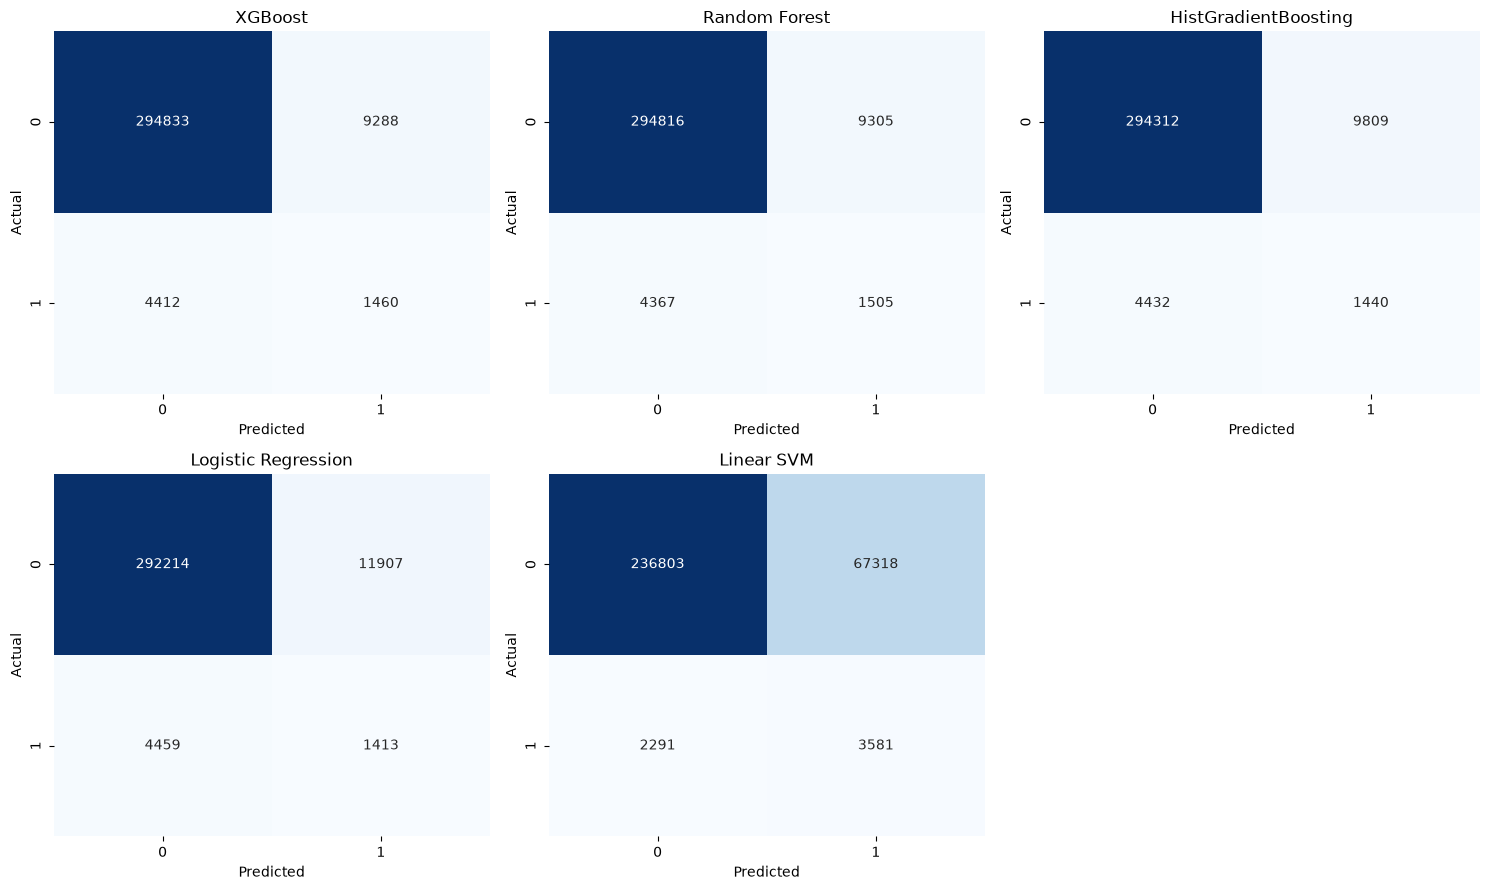

In [76]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

axes = axes.flatten()

for i, (model_name, cm) in enumerate(confusion_matrices.items()):

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=axes[i]
    )

    axes[i].set_title(model_name)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

# Hide unused subplot
axes[-1].axis("off")

plt.tight_layout()
plt.show()

In [77]:
final_comparison = test_results_df.copy()

final_comparison = final_comparison[
    [
        "Model",
        "PR-AUC",
        "ROC-AUC",
        "Threshold",
        "Precision",
        "Recall",
        "F1",
        "Accuracy"
    ]
]

final_comparison

,Model,PR-AUC,ROC-AUC,Threshold,Precision,Recall,F1,Accuracy
0,XGBoost,0.092856,0.791266,0.80,0.135839,0.248638,0.175692,0.955805
1,Random Forest,0.091238,0.787584,0.80,0.139223,0.256301,0.180434,0.955896
2,HistGradientBoosting,0.088892,0.786422,0.80,0.128011,0.245232,0.168214,0.954060
3,Logistic Regression,0.073414,0.743265,0.75,0.106081,0.240634,0.147249,0.947205
4,Linear SVM,0.071523,0.744026,0.00,0.050508,0.609843,0.093290,0.775450


In [79]:
final_comparison_display = final_comparison.copy()

metric_columns = [
    "PR-AUC",
    "ROC-AUC",
    "Precision",
    "Recall",
    "F1",
    "Accuracy"
]

final_comparison_display[metric_columns] = (
    final_comparison_display[metric_columns].round(4)
)

final_comparison_display

,Model,PR-AUC,ROC-AUC,Threshold,Precision,Recall,F1,Accuracy
0,XGBoost,0.0929,0.7913,0.80,0.1358,0.2486,0.1757,0.9558
1,Random Forest,0.0912,0.7876,0.80,0.1392,0.2563,0.1804,0.9559
2,HistGradientBoosting,0.0889,0.7864,0.80,0.1280,0.2452,0.1682,0.9541
3,Logistic Regression,0.0734,0.7433,0.75,0.1061,0.2406,0.1472,0.9472
4,Linear SVM,0.0715,0.7440,0.00,0.0505,0.6098,0.0933,0.7754


In [80]:
validation_comparison = pd.DataFrame({
    "Model": [
        "XGBoost",
        "Random Forest",
        "HistGradientBoosting",
        "Logistic Regression",
        "Linear SVM"
    ],
    "PR-AUC": [
        0.091780,
        0.085073,
        0.083325,
        0.073398,
        0.070716
    ],
    "ROC-AUC": [
        0.785275,
        0.781099,
        0.782045,
        0.735228,
        0.735272
    ],
    "Threshold": [
        0.80,
        0.80,
        0.80,
        0.75,
        0.00
    ],
    "Precision": [
        0.141187,
        0.141078,
        0.133402,
        0.097195,
        0.043701
    ],
    "Recall": [
        0.278458,
        0.285663,
        0.281700,
        0.265850,
        0.592579
    ],
    "F1": [
        0.187371,
        0.188877,
        0.181060,
        0.142347,
        0.081399
    ]
})

validation_comparison

,Model,PR-AUC,ROC-AUC,Threshold,Precision,Recall,F1
0,XGBoost,0.091780,0.785275,0.80,0.141187,0.278458,0.187371
1,Random Forest,0.085073,0.781099,0.80,0.141078,0.285663,0.188877
2,HistGradientBoosting,0.083325,0.782045,0.80,0.133402,0.281700,0.181060
3,Logistic Regression,0.073398,0.735228,0.75,0.097195,0.265850,0.142347
4,Linear SVM,0.070716,0.735272,0.00,0.043701,0.592579,0.081399


In [81]:
os.makedirs("../results", exist_ok=True)

validation_comparison.to_csv(
    "../results/validation_model_comparison.csv",
    index=False
)

final_comparison.to_csv(
    "../results/test_model_comparison.csv",
    index=False
)

print("Comparison results saved.")

Comparison results saved.


___
___

## Conclusion

This notebook compared five machine learning models for sepsis prediction using the same patient-level data split and final feature set.

The models evaluated were:

- XGBoost
- Random Forest
- HistGradientBoosting
- Logistic Regression
- Linear SVM

Precision-Recall AUC (PR-AUC) was used as the primary ranking metric because the dataset is highly imbalanced.

Model comparison and threshold selection were performed using the validation set. The test set was then used for final performance evaluation using the selected thresholds.

The final evaluation included PR-AUC, ROC-AUC, precision, recall, F1-score, accuracy, and confusion matrices.

The results show that the tree-based models achieved similar performance, while the linear models showed different precision-recall trade-offs. The results also demonstrate that model performance depends strongly on the classification threshold, particularly for an imbalanced medical prediction problem.

These results are intended for educational and research purposes and should not be interpreted as a clinical diagnostic system.

___
___